In [1]:
import sys
import tensorflow as tf
import numpy as np

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

print("\nTensorFlow device(s):")
print(tf.config.list_physical_devices())

print("\nPlantVision DL environment ready!")


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
TensorFlow: 2.21.0
NumPy: 2.5.1

TensorFlow device(s):
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

PlantVision DL environment ready!


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
possible_paths = [
    Path("../data/raw/PlantVillage/color"),
    Path("data/raw/PlantVillage/color")
]

DATASET_PATH = None

for path in possible_paths:
    if path.exists():
        DATASET_PATH = path
        break

print("Dataset:", DATASET_PATH)

Dataset: ..\data\raw\PlantVillage\color


In [4]:
selected_plants = [
    "Tomato",
    "Apple",
    "Grape",
    "Corn_(maize)",
    "Potato",
    "Pepper,_bell"
]

selected_class_folders = []

for folder in DATASET_PATH.iterdir():

    if not folder.is_dir():
        continue

    if "___" not in folder.name:
        continue

    plant = folder.name.split("___", 1)[0]

    if plant in selected_plants:
        selected_class_folders.append(folder)

selected_class_folders = sorted(selected_class_folders)

print("Number of DL classes:", len(selected_class_folders))

for folder in selected_class_folders:
    print(folder.name)

Number of DL classes: 27
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [5]:
image_data = []

valid_extensions = {
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
}

for folder in selected_class_folders:

    class_name = folder.name

    for image_path in folder.iterdir():

        if image_path.suffix in valid_extensions:

            image_data.append({
                "image_path": str(image_path),
                "class": class_name
            })

dl_df = pd.DataFrame(image_data)

print("Total DL images:", len(dl_df))
print("Number of classes:", dl_df["class"].nunique())

dl_df.head()

Total DL images: 34329
Number of classes: 27


,image_path,class
0,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple___Apple_scab
1,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple___Apple_scab
2,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple___Apple_scab
3,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple___Apple_scab
4,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple___Apple_scab


In [6]:
MAX_DL_IMAGES = 600

sampled_classes = []

for class_name, group in dl_df.groupby("class"):

    n = min(
        len(group),
        MAX_DL_IMAGES
    )

    sampled = group.sample(
        n=n,
        random_state=42
    )

    sampled_classes.append(sampled)

dl_sample_df = pd.concat(
    sampled_classes,
    ignore_index=True
)

print("Images selected:", len(dl_sample_df))
print("Classes:", dl_sample_df["class"].nunique())

print("\nImages per class:")
print(dl_sample_df["class"].value_counts())

Images selected: 14936
Classes: 27

Images per class:
class
Apple___Apple_scab                                    600
Apple___Black_rot                                     600
Apple___healthy                                       600
Corn_(maize)___Common_rust_                           600
Corn_(maize)___Northern_Leaf_Blight                   600
Corn_(maize)___healthy                                600
Grape___Black_rot                                     600
Grape___Esca_(Black_Measles)                          600
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            600
Pepper,_bell___Bacterial_spot                         600
Pepper,_bell___healthy                                600
Potato___Early_blight                                 600
Potato___Late_blight                                  600
Tomato___Bacterial_spot                               600
Tomato___Early_blight                                 600
Tomato___Late_blight                                  600
Tomato___Lea

In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    dl_sample_df,
    test_size=0.30,
    random_state=42,
    stratify=dl_sample_df["class"]
)

print("Training images:", len(train_df))
print("Temporary images:", len(temp_df))

Training images: 10455
Temporary images: 4481


In [8]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training images: 10455
Validation images: 2240
Testing images: 2241

Total: 14936


In [9]:
print("Train classes:", train_df["class"].nunique())
print("Validation classes:", val_df["class"].nunique())
print("Test classes:", test_df["class"].nunique())

Train classes: 27
Validation classes: 27
Test classes: 27


In [10]:
split_distribution = pd.DataFrame({
    "Train": train_df["class"].value_counts(),
    "Validation": val_df["class"].value_counts(),
    "Test": test_df["class"].value_counts()
}).fillna(0).astype(int)

split_distribution

,Train,Validation,Test
class,,,
Apple___Apple_scab,420,90,90
Apple___Black_rot,420,90,90
Apple___Cedar_apple_rust,193,41,41
Apple___healthy,420,90,90
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,77,77
Corn_(maize)___Common_rust_,420,90,90
Corn_(maize)___Northern_Leaf_Blight,420,90,90
Corn_(maize)___healthy,420,90,90
Grape___Black_rot,420,90,90


In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 54762 files belonging to 38 classes.


In [13]:
class_names = sorted(dl_sample_df["class"].unique())

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Number of classes:", len(class_names))

for name, index in class_to_index.items():
    print(index, "→", name)

Number of classes: 27
0 → Apple___Apple_scab
1 → Apple___Black_rot
2 → Apple___Cedar_apple_rust
3 → Apple___healthy
4 → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
5 → Corn_(maize)___Common_rust_
6 → Corn_(maize)___Northern_Leaf_Blight
7 → Corn_(maize)___healthy
8 → Grape___Black_rot
9 → Grape___Esca_(Black_Measles)
10 → Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
11 → Grape___healthy
12 → Pepper,_bell___Bacterial_spot
13 → Pepper,_bell___healthy
14 → Potato___Early_blight
15 → Potato___Late_blight
16 → Potato___healthy
17 → Tomato___Bacterial_spot
18 → Tomato___Early_blight
19 → Tomato___Late_blight
20 → Tomato___Leaf_Mold
21 → Tomato___Septoria_leaf_spot
22 → Tomato___Spider_mites Two-spotted_spider_mite
23 → Tomato___Target_Spot
24 → Tomato___Tomato_Yellow_Leaf_Curl_Virus
25 → Tomato___Tomato_mosaic_virus
26 → Tomato___healthy


In [14]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df["class"].map(class_to_index)
val_df["label"] = val_df["class"].map(class_to_index)
test_df["label"] = test_df["class"].map(class_to_index)

train_df[["class", "label"]].head()

,class,label
7728,"Pepper,_bell___healthy",13
11291,Tomato___Leaf_Mold,20
14023,Tomato___Tomato_mosaic_virus,25
5980,Grape___Leaf_blight_(Isariopsis_Leaf_Spot),10
7320,"Pepper,_bell___healthy",13


In [15]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [16]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def create_dataset(dataframe, training=False):

    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [17]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df
)

test_ds = create_dataset(
    test_df
)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


In [18]:
for images, labels in train_ds.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("Image dtype:", images.dtype)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0


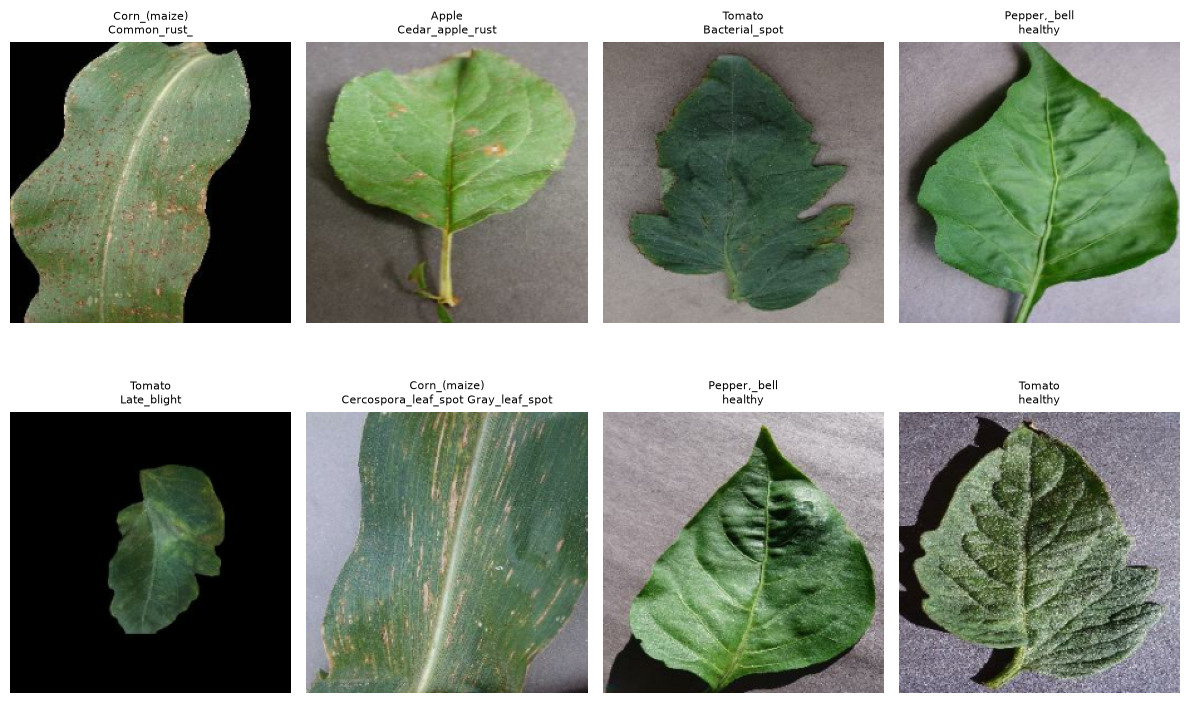

In [19]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            tf.cast(images[i], tf.uint8)
        )

        label_index = int(labels[i].numpy())

        plt.title(
            class_names[label_index]
            .replace("___", "\n"),
            fontsize=8
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

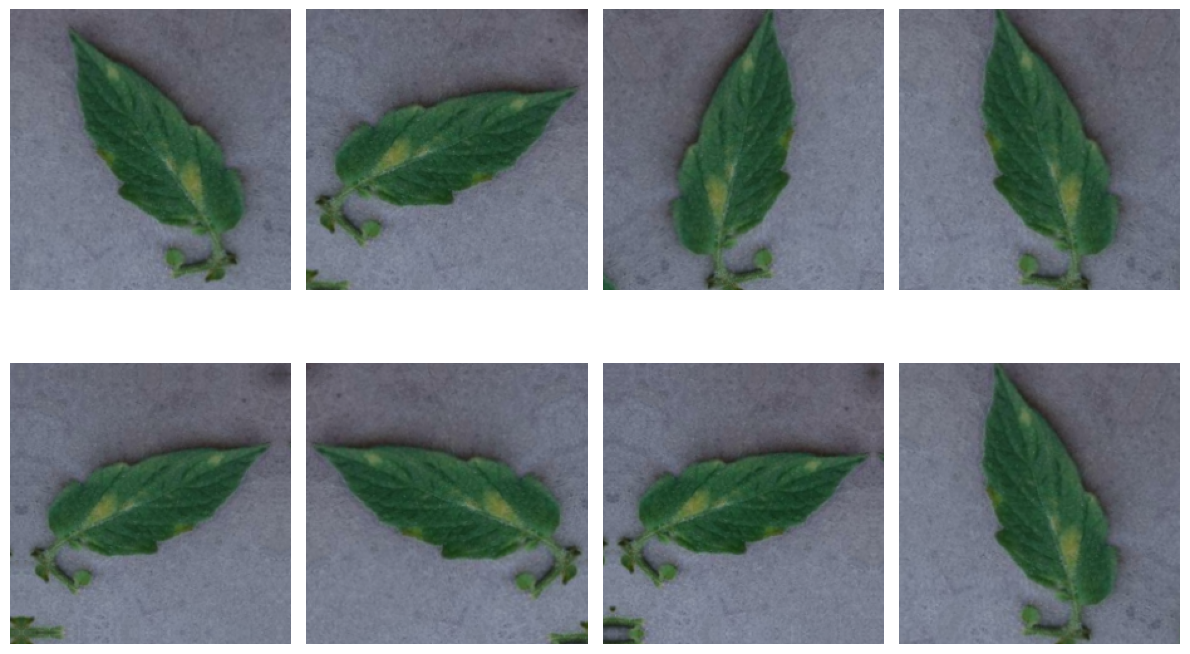

In [21]:
for images, labels in train_ds.take(1):

    sample_image = images[0]

    plt.figure(figsize=(12, 8))

    for i in range(8):

        augmented = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        plt.subplot(2, 4, i + 1)
        plt.imshow(
            tf.cast(augmented[0], tf.uint8)
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [22]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded!")
print("Base model layers:", len(base_model.layers))

MobileNetV2 loaded!
Base model layers: 154


In [23]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

NUM_CLASSES = len(class_names)

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# Augmentation
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing
x = preprocess_input(x)

# Pretrained feature extractor
x = base_model(
    x,
    training=False
)

# Convert feature maps into feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.30)(x)

# Final 27-class classifier
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="PlantVision_MobileNetV2"
)

In [24]:
model.summary()

Model: "PlantVision_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,571 (8.75 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("PlantVision model compiled!")

PlantVision model compiled!


In [26]:
from pathlib import Path

DL_MODEL_DIR = Path("models")
DL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    DL_MODEL_DIR /
    "plantvision_mobilenet_best.keras"
)

In [27]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [28]:
for images, labels in train_ds.take(1):

    predictions = model(
        images,
        training=False
    )

    print("Input shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Prediction shape:", predictions.shape)

    print(
        "Probability sum for first image:",
        tf.reduce_sum(predictions[0]).numpy()
    )

Input shape: (32, 224, 224, 3)
Label shape: (32,)
Prediction shape: (32, 27)
Probability sum for first image: 1.0


In [29]:
INITIAL_EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/8


c:\Users\adity\OneDrive\Desktop\PlantVision-AI\.venv-dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


327/327 ━━━━━━━━━━━━━━━━━━━━ 121s 348ms/step - accuracy: 0.6734 - loss: 1.1427 - val_accuracy: 0.8460 - val_loss: 0.5599 - learning_rate: 0.0010
Epoch 2/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 128s 306ms/step - accuracy: 0.8395 - loss: 0.5118 - val_accuracy: 0.8701 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 3/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 101s 310ms/step - accuracy: 0.8681 - loss: 0.4170 - val_accuracy: 0.8942 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 4/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 107s 328ms/step - accuracy: 0.8871 - loss: 0.3525 - val_accuracy: 0.9022 - val_loss: 0.3280 - learning_rate: 0.0010
Epoch 5/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 133s 302ms/step - accuracy: 0.8950 - loss: 0.3314 - val_accuracy: 0.8933 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 6/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 106s 323ms/step - accuracy: 0.9004 - loss: 0.3082 - val_accuracy: 0.9040 - val_loss: 0.3098 - learning_rate: 0.0010
Epoch 7/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 106s 324ms/step - accuracy: 0.9022 - loss

In [30]:
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_acc) + 1)

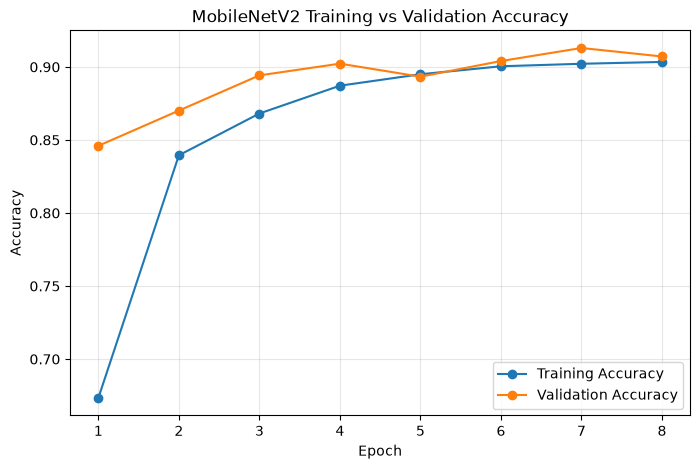

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

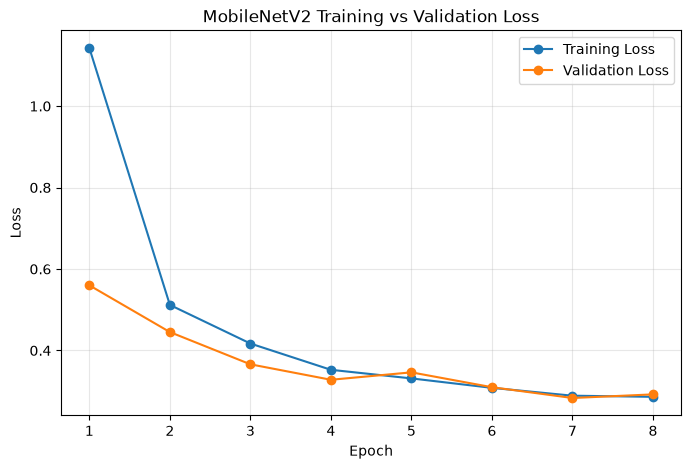

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
best_epoch = np.argmax(val_acc)

print(
    "Best epoch:",
    best_epoch + 1
)

print(
    "Best validation accuracy:",
    round(
        val_acc[best_epoch] * 100,
        2
    ),
    "%"
)

print(
    "Validation loss at best epoch:",
    round(
        val_loss[best_epoch],
        4
    )
)

Best epoch: 7
Best validation accuracy: 91.29 %
Validation loss at best epoch: 0.2833


In [34]:
base_model.trainable = True

print("Total MobileNetV2 layers:", len(base_model.layers))

Total MobileNetV2 layers: 154


In [35]:
FINE_TUNE_AT = 120

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Trainable MobileNetV2 layers:", trainable_count)

Trainable MobileNetV2 layers: 34


In [36]:
FINE_TUNE_AT = 120

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Trainable MobileNetV2 layers:", trainable_count)

Trainable MobileNetV2 layers: 34


In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [38]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "models/plantvision_mobilenet_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [39]:
FINE_TUNE_EPOCHS = 5

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 134s 382ms/step - accuracy: 0.7475 - loss: 0.9115 - val_accuracy: 0.8786 - val_loss: 0.3547 - learning_rate: 1.0000e-05
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 126s 387ms/step - accuracy: 0.8719 - loss: 0.3927 - val_accuracy: 0.8902 - val_loss: 0.3398 - learning_rate: 1.0000e-05
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 124s 380ms/step - accuracy: 0.8914 - loss: 0.3234 - val_accuracy: 0.8938 - val_loss: 0.3174 - learning_rate: 1.0000e-05
Epoch 4/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 127s 387ms/step - accuracy: 0.9106 - loss: 0.2695 - val_accuracy: 0.9027 - val_loss: 0.2902 - learning_rate: 1.0000e-05
Epoch 5/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 124s 378ms/step - accuracy: 0.9137 - loss: 0.2574 - val_accuracy: 0.9045 - val_loss: 0.2814 - learning_rate: 1.0000e-05


In [40]:
fine_train_acc = fine_history.history["accuracy"]
fine_val_acc = fine_history.history["val_accuracy"]

fine_train_loss = fine_history.history["loss"]
fine_val_loss = fine_history.history["val_loss"]

best_fine_epoch = np.argmax(fine_val_acc)

print(
    "Best fine-tuning epoch:",
    best_fine_epoch + 1
)

print(
    "Best fine-tuning validation accuracy:",
    round(
        fine_val_acc[best_fine_epoch] * 100,
        2
    ),
    "%"
)

print(
    "Validation loss:",
    round(
        fine_val_loss[best_fine_epoch],
        4
    )
)

Best fine-tuning epoch: 5
Best fine-tuning validation accuracy: 90.45 %
Validation loss: 0.2814


In [41]:
initial_best = max(
    history.history["val_accuracy"]
)

fine_best = max(
    fine_history.history["val_accuracy"]
)

print(
    "Before fine-tuning:",
    round(initial_best * 100, 2),
    "%"
)

print(
    "After fine-tuning:",
    round(fine_best * 100, 2),
    "%"
)

print(
    "Improvement:",
    round(
        (fine_best - initial_best) * 100,
        2
    ),
    "percentage points"
)

Before fine-tuning: 91.29 %
After fine-tuning: 90.45 %
Improvement: -0.85 percentage points


In [42]:
best_model = tf.keras.models.load_model(
    "models/plantvision_mobilenet_finetuned.keras"
)

print("Best model loaded!")

Best model loaded!


In [43]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Test Loss:", round(test_loss, 4))
print(
    "Final Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.9161 - loss: 0.2550

Final Test Loss: 0.255
Final Test Accuracy: 91.61 %


In [44]:
y_true = []
y_pred = []
y_confidence = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    confidence = np.max(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_confidence.extend(confidence)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_confidence = np.array(y_confidence)

print("Total test predictions:", len(y_pred))

Total test predictions: 2241


In [45]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.96      0.96        90
                                 Apple___Black_rot       0.99      1.00      0.99        90
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        41
                                   Apple___healthy       0.96      0.97      0.96        90
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.81      0.86        77
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99        90
               Corn_(maize)___Northern_Leaf_Blight       0.84      0.94      0.89        90
                            Corn_(maize)___healthy       1.00      1.00      1.00        90
                                 Grape___Black_rot       0.97      0.99      0.98        90
                      Grape___Esca_(Black_Measles)       0.99      0.97      0.

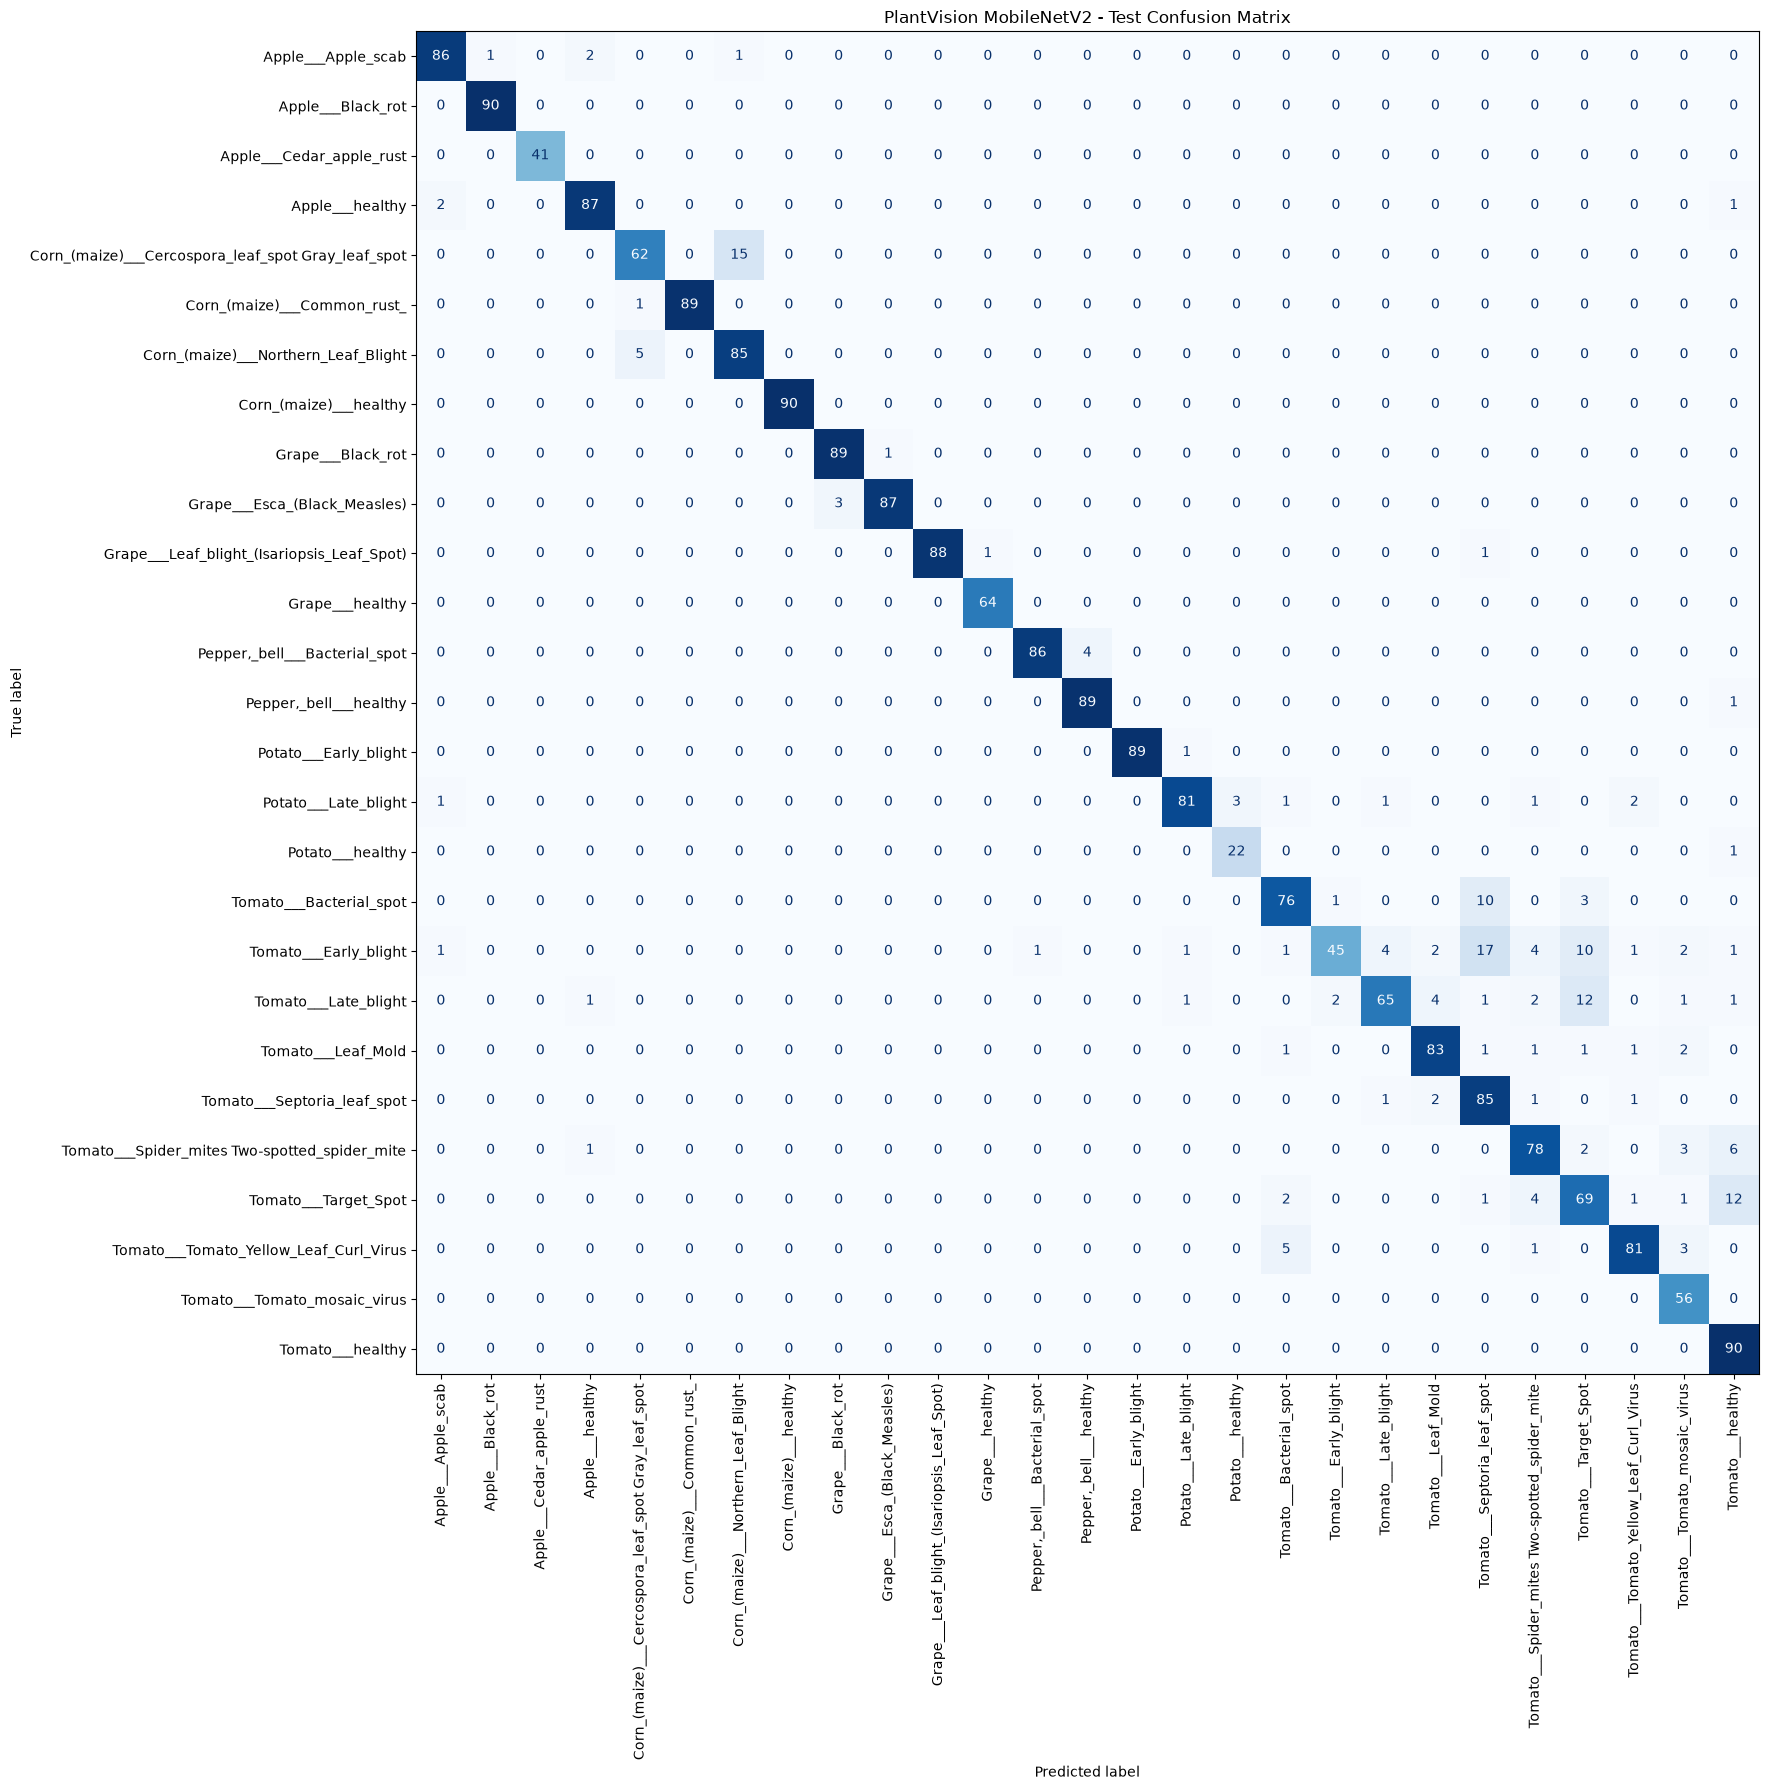

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dl = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(18, 18)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "PlantVision MobileNetV2 - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [47]:
confusions = []

for true_index in range(len(class_names)):

    for pred_index in range(len(class_names)):

        if true_index != pred_index:

            count = cm_dl[
                true_index,
                pred_index
            ]

            if count > 0:

                confusions.append({
                    "Actual": class_names[true_index],
                    "Predicted": class_names[pred_index],
                    "Count": count
                })

confusion_df = pd.DataFrame(
    confusions
).sort_values(
    "Count",
    ascending=False
)

confusion_df.head(10)

,Actual,Predicted,Count
31,Tomato___Early_blight,Tomato___Septoria_leaf_spot,17
5,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,15
65,Tomato___Target_Spot,Tomato___healthy,12
43,Tomato___Late_blight,Tomato___Target_Spot,12
23,Tomato___Bacterial_spot,Tomato___Septoria_leaf_spot,10
33,Tomato___Early_blight,Tomato___Target_Spot,10
59,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___healthy,6
66,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Bacterial_spot,5
7,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,5
12,"Pepper,_bell___Bacterial_spot","Pepper,_bell___healthy",4


In [48]:
for layer in base_model.layers[-20:]:
    print(layer.name, layer.output.shape)

block_15_expand (None, 7, 7, 960)
block_15_expand_BN (None, 7, 7, 960)
block_15_expand_relu (None, 7, 7, 960)
block_15_depthwise (None, 7, 7, 960)
block_15_depthwise_BN (None, 7, 7, 960)
block_15_depthwise_relu (None, 7, 7, 960)
block_15_project (None, 7, 7, 160)
block_15_project_BN (None, 7, 7, 160)
block_15_add (None, 7, 7, 160)
block_16_expand (None, 7, 7, 960)
block_16_expand_BN (None, 7, 7, 960)
block_16_expand_relu (None, 7, 7, 960)
block_16_depthwise (None, 7, 7, 960)
block_16_depthwise_BN (None, 7, 7, 960)
block_16_depthwise_relu (None, 7, 7, 960)
block_16_project (None, 7, 7, 320)
block_16_project_BN (None, 7, 7, 320)
Conv_1 (None, 7, 7, 1280)
Conv_1_bn (None, 7, 7, 1280)
out_relu (None, 7, 7, 1280)


In [49]:
LAST_CONV_LAYER = "out_relu"

Actual class:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot


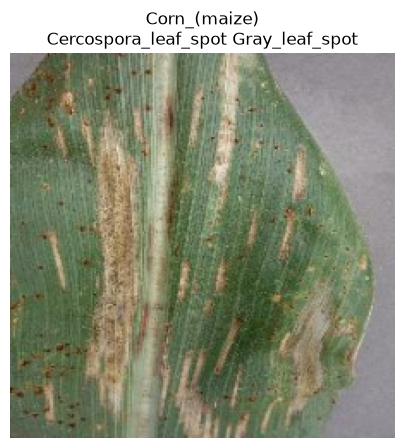

In [50]:
for test_images, test_labels in test_ds.take(1):
    sample_image = test_images[0]
    sample_label = int(test_labels[0].numpy())

print("Actual class:")
print(class_names[sample_label])

plt.figure(figsize=(5, 5))
plt.imshow(
    tf.cast(sample_image, tf.uint8)
)
plt.title(
    class_names[sample_label].replace("___", "\n")
)
plt.axis("off")
plt.show()

In [51]:
sample_batch = tf.expand_dims(
    sample_image,
    axis=0
)

prediction = best_model.predict(
    sample_batch,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

confidence = np.max(
    prediction[0]
)

print(
    "Actual:",
    class_names[sample_label]
)

print(
    "Predicted:",
    class_names[predicted_index]
)

print(
    "Confidence:",
    round(float(confidence) * 100, 2),
    "%"
)

Actual: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence: 61.38 %


In [52]:
for i, layer in enumerate(best_model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_2 InputLayer
1 data_augmentation Sequential
2 mobilenetv2_1.00_224 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dropout Dropout
5 dense Dense


In [53]:
mobilenet_layer = None

for layer in best_model.layers:
    if isinstance(layer, tf.keras.Model):
        if "mobilenet" in layer.name.lower():
            mobilenet_layer = layer
            break

print("MobileNet layer:", mobilenet_layer.name)

MobileNet layer: mobilenetv2_1.00_224


In [54]:
# Get the last convolutional layer inside MobileNetV2
last_conv_layer = mobilenet_layer.get_layer("out_relu")

# Model from MobileNet input -> last conv output
conv_model = tf.keras.Model(
    inputs=mobilenet_layer.input,
    outputs=last_conv_layer.output
)

print("Last conv layer:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Last conv layer: out_relu
Output shape: (None, 7, 7, 1280)


In [55]:
def make_gradcam_heatmap(
    image,
    full_model,
    mobilenet_model,
    conv_model
):
    # Add batch dimension if needed
    if len(image.shape) == 3:
        image = tf.expand_dims(image, axis=0)

    image = tf.cast(image, tf.float32)

    # Apply same preprocessing used during training
    preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    with tf.GradientTape() as tape:

        # Get convolutional feature maps
        conv_outputs = conv_model(
            preprocessed,
            training=False
        )

        tape.watch(conv_outputs)

        # Continue through the remaining MobileNetV2 layers
        x = conv_outputs

        start_processing = False

        for layer in mobilenet_model.layers:

            if layer.name == "out_relu":
                start_processing = True
                continue

            if start_processing:
                x = layer(x, training=False)

        # Apply layers after MobileNetV2 in our PlantVision model
        mobile_index = full_model.layers.index(
            mobilenet_model
        )

        for layer in full_model.layers[
            mobile_index + 1:
        ]:
            x = layer(x, training=False)

        predictions = x

        predicted_class = tf.argmax(
            predictions[0]
        )

        class_score = predictions[
            :,
            predicted_class
        ]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    # Keep positive influence
    heatmap = tf.maximum(
        heatmap,
        0
    )

    maximum = tf.reduce_max(heatmap)

    if maximum > 0:
        heatmap = heatmap / maximum

    return (
        heatmap.numpy(),
        int(predicted_class.numpy())
    )

In [56]:
heatmap, gradcam_class = make_gradcam_heatmap(
    sample_image,
    best_model,
    mobilenet_layer,
    conv_model
)

print(
    "Grad-CAM predicted class:",
    class_names[gradcam_class]
)

print(
    "Heatmap shape:",
    heatmap.shape
)

Grad-CAM predicted class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Heatmap shape: (7, 7)


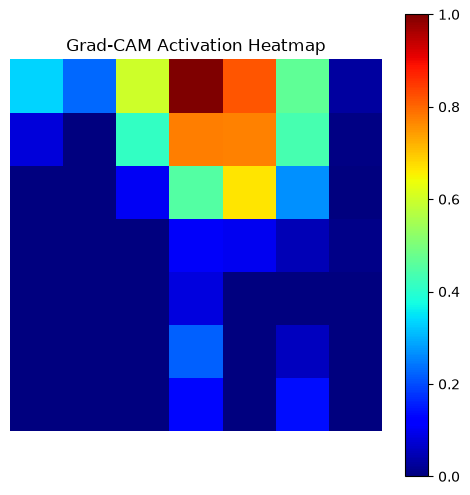

In [57]:
plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title("Grad-CAM Activation Heatmap")
plt.colorbar()

plt.axis("off")
plt.show()

In [58]:
import cv2

original_image = sample_image.numpy().astype(
    np.uint8
)

# Resize Grad-CAM to image dimensions
heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)

# Convert 0-1 -> 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply heatmap
colored_heatmap = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# OpenCV BGR -> RGB
colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB
)

# Overlay
gradcam_overlay = cv2.addWeighted(
    original_image,
    0.6,
    colored_heatmap,
    0.4,
    0
)

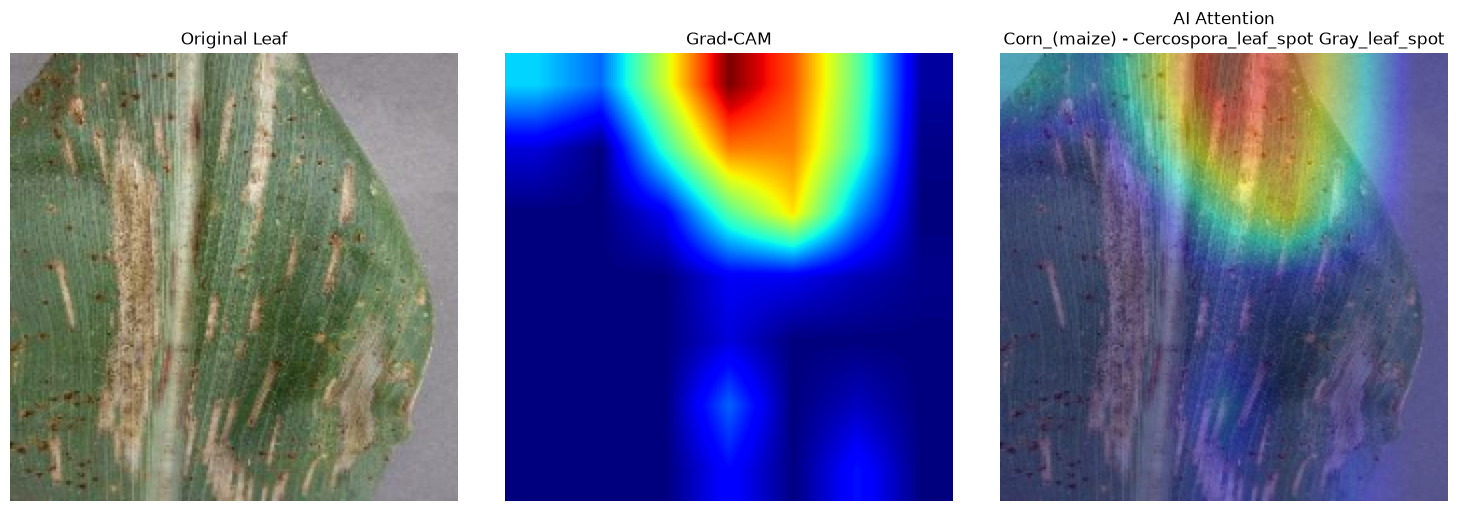

In [59]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Leaf")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    heatmap_resized,
    cmap="jet"
)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradcam_overlay)

plt.title(
    "AI Attention\n"
    + class_names[gradcam_class].replace(
        "___",
        " - "
    )
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [60]:
def format_prediction(class_name):

    plant, disease = class_name.split("___", 1)

    plant = (
        plant
        .replace("_", " ")
        .replace(",", "")
        .strip()
        .title()
    )

    disease = (
        disease
        .replace("_", " ")
        .strip()
        .title()
    )

    return plant, disease

In [61]:
plant, disease = format_prediction(
    "Tomato___Late_blight"
)

print("Plant:", plant)
print("Disease:", disease)

Plant: Tomato
Disease: Late Blight


In [62]:
def predict_leaf(image_path):

    # Load image
    image = tf.io.read_file(str(image_path))

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [224, 224]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    # Add batch dimension
    batch = tf.expand_dims(
        image,
        axis=0
    )

    # Model prediction
    predictions = best_model.predict(
        batch,
        verbose=0
    )[0]

    # -------------------------
    # Main prediction
    # -------------------------
    predicted_index = int(
        np.argmax(predictions)
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = float(
        predictions[predicted_index]
    )

    plant, disease = format_prediction(
        predicted_class
    )

    # -------------------------
    # Top 3 predictions
    # -------------------------
    top_indices = np.argsort(
        predictions
    )[-3:][::-1]

    top_predictions = []

    for idx in top_indices:

        # Important fix
        idx = int(idx)

        top_class = class_names[idx]

        top_plant, top_disease = format_prediction(
            top_class
        )

        top_predictions.append({
            "plant": top_plant,
            "disease": top_disease,
            "class": top_class,
            "confidence": float(
                predictions[idx]
            )
        })

    # -------------------------
    # Return everything
    # -------------------------
    return {
        "plant": plant,
        "disease": disease,
        "class": predicted_class,
        "class_index": predicted_index,
        "confidence": confidence,
        "image": image.numpy(),
        "top_predictions": top_predictions
    }

In [63]:
test_image_path = test_df.iloc[0][
    "image_path"
]

result = predict_leaf(
    test_image_path
)

print("Plant:", result["plant"])
print("Disease:", result["disease"])

print(
    "Confidence:",
    round(
        result["confidence"] * 100,
        2
    ),
    "%"
)

Plant: Corn (Maize)
Disease: Cercospora Leaf Spot Gray Leaf Spot
Confidence: 61.38 %


In [64]:
print(
    "Actual:",
    test_df.iloc[0]["class"]
)

print(
    "Predicted:",
    result["class"]
)

Actual: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot


In [65]:
test_image_path = test_df.iloc[0]["image_path"]

result = predict_leaf(test_image_path)

print("Actual:", test_df.iloc[0]["class"])
print("Predicted:", result["class"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")

print("\nTop 3 Predictions")
print("------------------------------")

for i, pred in enumerate(result["top_predictions"], start=1):
    print(
        f"{i}. {pred['plant']} - {pred['disease']} "
        f"({pred['confidence'] * 100:.2f}%)"
    )

Actual: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence: 61.38%

Top 3 Predictions
------------------------------
1. Corn (Maize) - Cercospora Leaf Spot Gray Leaf Spot (61.38%)
2. Corn (Maize) - Northern Leaf Blight (38.42%)
3. Corn (Maize) - Common Rust (0.17%)


In [66]:
def analyze_affected_area(image_path):

    # Read image
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError("Could not read image.")

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    image_rgb = cv2.resize(
        image_rgb,
        (224, 224)
    )

    # Convert to HSV
    hsv = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2HSV
    )

    # --------------------------------
    # 1. Create leaf mask
    # --------------------------------
    lower_green = np.array([20, 25, 20])
    upper_green = np.array([100, 255, 255])

    green_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    kernel = np.ones((5, 5), np.uint8)

    leaf_mask = cv2.morphologyEx(
        green_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # --------------------------------
    # 2. Yellow/brown regions
    # --------------------------------
    lower_yellow = np.array([10, 40, 30])
    upper_yellow = np.array([40, 255, 255])

    yellow_mask = cv2.inRange(
        hsv,
        lower_yellow,
        upper_yellow
    )

    # --------------------------------
    # 3. Dark regions
    # --------------------------------
    lower_dark = np.array([0, 25, 0])
    upper_dark = np.array([180, 255, 95])

    dark_mask = cv2.inRange(
        hsv,
        lower_dark,
        upper_dark
    )

    # --------------------------------
    # 4. Combine abnormal regions
    # --------------------------------
    abnormal_mask = cv2.bitwise_or(
        yellow_mask,
        dark_mask
    )

    abnormal_mask = cv2.bitwise_and(
        abnormal_mask,
        leaf_mask
    )

    small_kernel = np.ones(
        (3, 3),
        np.uint8
    )

    abnormal_mask = cv2.morphologyEx(
        abnormal_mask,
        cv2.MORPH_OPEN,
        small_kernel
    )

    # --------------------------------
    # 5. Calculate percentage
    # --------------------------------
    leaf_pixels = cv2.countNonZero(
        leaf_mask
    )

    affected_pixels = cv2.countNonZero(
        abnormal_mask
    )

    if leaf_pixels > 0:
        affected_percentage = (
            affected_pixels /
            leaf_pixels
        ) * 100
    else:
        affected_percentage = 0

    return {
        "image": image_rgb,
        "leaf_mask": leaf_mask,
        "affected_mask": abnormal_mask,
        "affected_percentage":
            float(affected_percentage)
    }

In [67]:
area_result = analyze_affected_area(
    test_image_path
)

print(
    "Estimated visually affected area:",
    f'{area_result["affected_percentage"]:.2f}%'
)

Estimated visually affected area: 44.95%


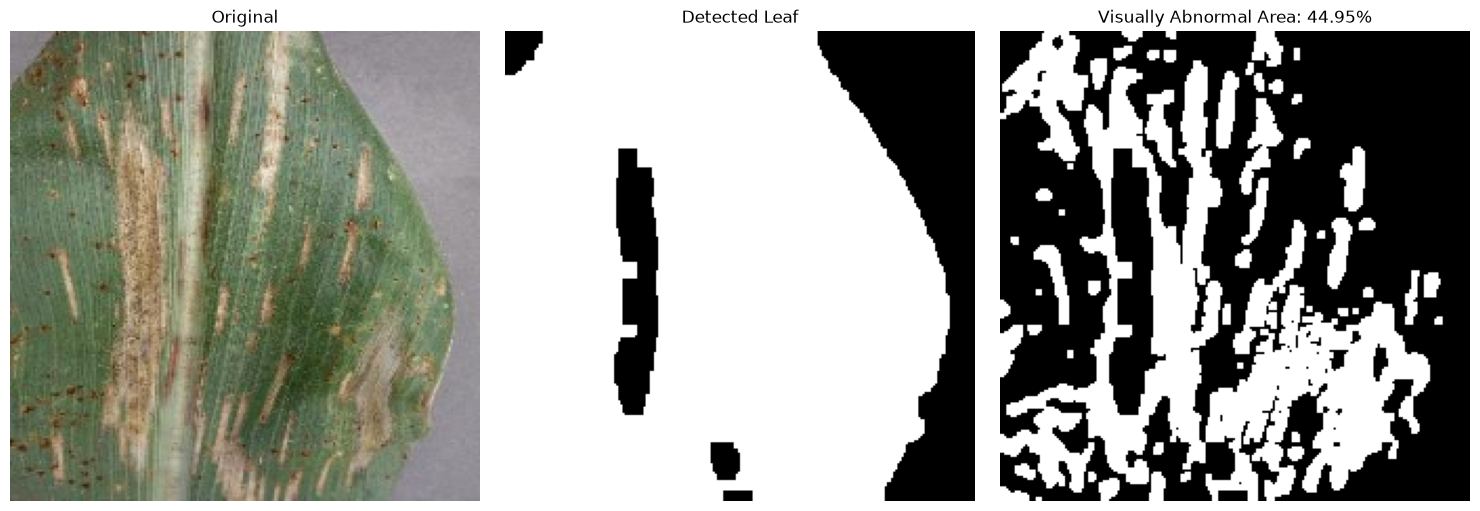

In [68]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(area_result["image"])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    area_result["leaf_mask"],
    cmap="gray"
)
plt.title("Detected Leaf")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    area_result["affected_mask"],
    cmap="gray"
)
plt.title(
    f'Visually Abnormal Area: '
    f'{area_result["affected_percentage"]:.2f}%'
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
healthy_row = test_df[
    test_df["class"].str.contains(
        "healthy",
        case=False
    )
].iloc[0]

healthy_result = analyze_affected_area(
    healthy_row["image_path"]
)

print("Healthy image:")
print(healthy_row["class"])

print(
    "Affected estimate:",
    f'{healthy_result["affected_percentage"]:.2f}%'
)

Healthy image:
Apple___healthy
Affected estimate: 77.08%


In [70]:
diseased_row = test_df[
    ~test_df["class"].str.contains(
        "healthy",
        case=False
    )
].iloc[0]

diseased_result = analyze_affected_area(
    diseased_row["image_path"]
)

print("Diseased image:")
print(diseased_row["class"])

print(
    "Affected estimate:",
    f'{diseased_result["affected_percentage"]:.2f}%'
)

Diseased image:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Affected estimate: 44.95%


In [71]:
def analyze_leaf(image_path):

    # -------------------------
    # 1. DL Disease Prediction
    # -------------------------
    prediction_result = predict_leaf(
        image_path
    )

    # -------------------------
    # 2. Affected Area Analysis
    # -------------------------
    area_result = analyze_affected_area(
        image_path
    )

    # -------------------------
    # 3. Basic result
    # -------------------------
    result = {
        "plant": prediction_result["plant"],
        "disease": prediction_result["disease"],
        "class": prediction_result["class"],
        "confidence": prediction_result["confidence"],
        "top_predictions":
            prediction_result["top_predictions"],

        "affected_percentage":
            area_result["affected_percentage"],

        "image":
            area_result["image"],

        "leaf_mask":
            area_result["leaf_mask"],

        "affected_mask":
            area_result["affected_mask"]
    }

    return result

In [72]:
final_result = analyze_leaf(
    test_image_path
)

print("PLANTVISION AI ANALYSIS")
print("=" * 40)

print(
    "Plant:",
    final_result["plant"]
)

print(
    "Disease:",
    final_result["disease"]
)

print(
    "Confidence:",
    f'{final_result["confidence"] * 100:.2f}%'
)

print(
    "Visually affected area:",
    f'{final_result["affected_percentage"]:.2f}%'
)

PLANTVISION AI ANALYSIS
Plant: Corn (Maize)
Disease: Cercospora Leaf Spot Gray Leaf Spot
Confidence: 61.38%
Visually affected area: 44.95%


In [73]:
print("\nTOP 3 PREDICTIONS")
print("=" * 40)

for i, pred in enumerate(
    final_result["top_predictions"],
    start=1
):

    print(
        f"{i}. "
        f"{pred['plant']} - "
        f"{pred['disease']} "
        f"({pred['confidence'] * 100:.2f}%)"
    )


TOP 3 PREDICTIONS
1. Corn (Maize) - Cercospora Leaf Spot Gray Leaf Spot (61.38%)
2. Corn (Maize) - Northern Leaf Blight (38.42%)
3. Corn (Maize) - Common Rust (0.17%)


In [74]:
def confidence_status(confidence):

    percentage = confidence * 100

    if percentage >= 85:
        return "High"

    elif percentage >= 65:
        return "Moderate"

    else:
        return "Low"

In [75]:
status = confidence_status(
    final_result["confidence"]
)

print("Prediction confidence:", status)

Prediction confidence: Low


In [76]:

test_samples = test_df.sample(
    20,
    random_state=100
)

test_results = []

for _, row in test_samples.iterrows():

    result = predict_leaf(row["image_path"])

    actual = row["class"]
    predicted = result["class"]
    confidence = result["confidence"]

    test_results.append({
        "Actual": actual,
        "Predicted": predicted,
        "Confidence": confidence * 100,
        "Status": confidence_status(confidence),
        "Correct": actual == predicted
    })

results_df = pd.DataFrame(test_results)

results_df


,Actual,Predicted,Confidence,Status,Correct
0,Corn_(maize)___Common_rust_,Corn_(maize)___Common_rust_,99.914861,High,True
1,Tomato___Tomato_mosaic_virus,Tomato___Tomato_mosaic_virus,92.000771,High,True
2,Apple___Cedar_apple_rust,Apple___Cedar_apple_rust,95.038617,High,True
3,Tomato___healthy,Tomato___healthy,98.138523,High,True
4,Potato___Late_blight,Potato___Late_blight,99.965358,High,True
5,"Pepper,_bell___Bacterial_spot","Pepper,_bell___Bacterial_spot",99.927860,High,True
6,Tomato___Septoria_leaf_spot,Tomato___Septoria_leaf_spot,92.864692,High,True
7,"Pepper,_bell___Bacterial_spot","Pepper,_bell___healthy",69.414783,Moderate,False
8,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Northern_Leaf_Blight,98.410195,High,True
9,"Pepper,_bell___healthy","Pepper,_bell___healthy",99.938130,High,True


In [77]:
print("TEST SUMMARY")
print("=" * 40)

print("Images tested:", len(results_df))

print(
    "Correct:",
    results_df["Correct"].sum()
)

print(
    "Incorrect:",
    (~results_df["Correct"]).sum()
)

print(
    "Sample accuracy:",
    f'{results_df["Correct"].mean() * 100:.2f}%'
)

print("\nConfidence distribution:")
print(results_df["Status"].value_counts())

TEST SUMMARY
Images tested: 20
Correct: 18
Incorrect: 2
Sample accuracy: 90.00%

Confidence distribution:
Status
High        17
Low          2
Moderate     1
Name: count, dtype: int64


In [78]:
uncertain_df = results_df[
    results_df["Status"] != "High"
].sort_values("Confidence")

uncertain_df

,Actual,Predicted,Confidence,Status,Correct
15,Tomato___Early_blight,Tomato___Early_blight,57.963306,Low,True
12,Tomato___Spider_mites Two-spotted_spider_mite,Apple___healthy,59.402490,Low,False
7,"Pepper,_bell___Bacterial_spot","Pepper,_bell___healthy",69.414783,Moderate,False


In [79]:
def prediction_message(confidence):

    percentage = confidence * 100

    if percentage >= 85:
        return "High confidence prediction"

    elif percentage >= 65:
        return (
            "Moderate confidence — "
            "consider uploading another clear image"
        )

    else:
        return (
            "Low confidence — prediction may be unreliable. "
            "Try another clear leaf image."
        )

In [80]:
message = prediction_message(
    final_result["confidence"]
)

print(message)

Low confidence — prediction may be unreliable. Try another clear leaf image.


In [81]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nModels folder exists:")
print(Path("../models").exists())

print("\nData folder exists:")
print(Path("../data").exists())

Current working directory:
c:\Users\adity\OneDrive\Desktop\PlantVision-AI\notebooks

Models folder exists:
True

Data folder exists:
True


In [84]:
from pathlib import Path

DATASET_PATH = Path("../data/raw/PlantVillage/color")

selected_plants = [
    "Tomato",
    "Apple",
    "Grape",
    "Corn_(maize)",
    "Potato",
    "Pepper,_bell"
]

class_names = sorted([
    folder.name
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
    and "___" in folder.name
    and folder.name.split("___", 1)[0] in selected_plants
])

print("Total classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, "→", name)

Total classes: 27
0 → Apple___Apple_scab
1 → Apple___Black_rot
2 → Apple___Cedar_apple_rust
3 → Apple___healthy
4 → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
5 → Corn_(maize)___Common_rust_
6 → Corn_(maize)___Northern_Leaf_Blight
7 → Corn_(maize)___healthy
8 → Grape___Black_rot
9 → Grape___Esca_(Black_Measles)
10 → Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
11 → Grape___healthy
12 → Pepper,_bell___Bacterial_spot
13 → Pepper,_bell___healthy
14 → Potato___Early_blight
15 → Potato___Late_blight
16 → Potato___healthy
17 → Tomato___Bacterial_spot
18 → Tomato___Early_blight
19 → Tomato___Late_blight
20 → Tomato___Leaf_Mold
21 → Tomato___Septoria_leaf_spot
22 → Tomato___Spider_mites Two-spotted_spider_mite
23 → Tomato___Target_Spot
24 → Tomato___Tomato_Yellow_Leaf_Curl_Virus
25 → Tomato___Tomato_mosaic_virus
26 → Tomato___healthy


In [ ]:
import pickle

CLASS_FILE = Path("../models/class_names.pkl")

with open(CLASS_FILE, "wb") as f:
    pickle.dump(class_names, f)

print("Saved to:", CLASS_FILE)
print("Number of classes saved:", len(class_names))

Saved to: ..\models\class_names.pkl
Number of classes saved: 27


: 